<a href="https://colab.research.google.com/github/normie-6923/autobot/blob/main/mlproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Successfully loaded 60000 training images and 10000 testing images!


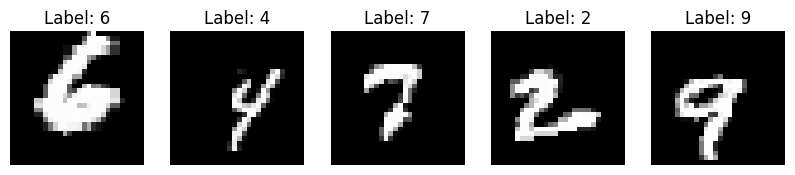

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Setup Data Transformations
# The Upgraded Data Transformation Pipeline
augmented_transform = transforms.Compose([
    transforms.RandomRotation(15), # Randomly tilts the image up to 15 degrees left or right
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.1)), # Randomly shifts it off-center and shrinks/grows it
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Downloading Augmented MNIST dataset...")
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=augmented_transform)

# NOTE: We do NOT augment the test dataset. We want the final exam to remain standard.
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

# Recreate the loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print(f"Successfully loaded {len(train_dataset)} training images and {len(test_dataset)} testing images!")

# 4. Grab a batch and plot 5 sample digits visually
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

plt.show()

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__() # This sets up the base PyTorch requirements

        # 1. The Hidden Layer (The internal processor)
        # An image is 28x28 pixels, which equals 784 total pixels.
        # We connect those 784 pixels to 128 "hidden neurons".
        self.hidden_layer = nn.Linear(in_features=784, out_features=128)

        # 2. The Output Layer (The final guess)
        # We take the 128 hidden neurons and connect them to 10 output neurons.
        # Why 10? Because our answers are the digits 0 through 9.
        self.output_layer = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
        # 1. Flatten the image
        # x comes in as a 2D grid (28x28). MLPs need a flat 1D line (784).
        # .view(x.size(0), -1) flattens the image while keeping the batch size intact.
        x = x.view(x.size(0), -1)

        # 2. Pass data into the hidden layer
        x = self.hidden_layer(x)

        # 3. Apply the Activation Function (ReLU)
        # ReLU acts like a filter: if a number is negative, it turns it to 0.
        # Without this, the network can only learn straight lines. This lets it learn curves!
        x = F.relu(x)

        # 4. Pass data to the output layer for the final 10 probabilities
        x = self.output_layer(x)

        return x

# Create an instance of our network
model = SimpleMLP()
print(model)

SimpleMLP(
  (hidden_layer): Linear(in_features=784, out_features=128, bias=True)
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
)


In [4]:
import torch.optim as optim

# 1. Connect to the GPU
# We turned on the T4 GPU earlier, but PyTorch needs explicit instructions to use it.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

# 2. The Loss Function (The Teacher)
# CrossEntropyLoss is the standard for multiple-choice problems (0 through 9).
criterion = nn.CrossEntropyLoss()

# 3. The Optimizer (The Mechanic)
# Adam is a very popular, highly efficient optimizer.
# We hand it 'model.parameters()' (all the wires in our network) so it knows what to adjust.
# lr=0.001 is the "Learning Rate" — how big of an adjustment it makes each time.
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training on: cuda


In [5]:
# Number of times the AI will look at the ENTIRE dataset (60,000 images)
epochs = 5

print("Starting training...")

for epoch in range(epochs):
    running_loss = 0.0

    # Loop through the data loader (which gives us 64 images at a time)
    for batch_idx, (images, labels) in enumerate(train_loader):

        # 1. Send the images and answers to the GPU
        images = images.to(device)
        labels = labels.to(device)

        # 2. Clear out the old adjustments (crucial in PyTorch!)
        optimizer.zero_grad()

        # 3. Forward Pass: The AI makes its guess
        outputs = model(images)

        # 4. Calculate the Loss: The Teacher grades the guess
        loss = criterion(outputs, labels)

        # 5. Backward Pass: Figure out which wires to adjust (Calculus magic)
        loss.backward()

        # 6. Step: The Mechanic actually updates the wires
        optimizer.step()

        # Keep track of the loss so we can print it
        running_loss += loss.item()

        # Print an update every 300 batches
        if batch_idx % 300 == 299:
            print(f"Epoch [{epoch+1}/{epochs}] - Batch [{batch_idx+1}/{len(train_loader)}] - Loss: {running_loss/300:.4f}")
            running_loss = 0.0 # Reset for the next 300 batches

print("Training Complete! The brain is fully wired.")

Starting training...
Epoch [1/5] - Batch [300/938] - Loss: 1.4503
Epoch [1/5] - Batch [600/938] - Loss: 1.0285
Epoch [1/5] - Batch [900/938] - Loss: 0.7821
Epoch [2/5] - Batch [300/938] - Loss: 0.6322
Epoch [2/5] - Batch [600/938] - Loss: 0.5774
Epoch [2/5] - Batch [900/938] - Loss: 0.5072
Epoch [3/5] - Batch [300/938] - Loss: 0.4778
Epoch [3/5] - Batch [600/938] - Loss: 0.4411
Epoch [3/5] - Batch [900/938] - Loss: 0.4180
Epoch [4/5] - Batch [300/938] - Loss: 0.4127
Epoch [4/5] - Batch [600/938] - Loss: 0.3871
Epoch [4/5] - Batch [900/938] - Loss: 0.3991
Epoch [5/5] - Batch [300/938] - Loss: 0.3781
Epoch [5/5] - Batch [600/938] - Loss: 0.3727
Epoch [5/5] - Batch [900/938] - Loss: 0.3629
Training Complete! The brain is fully wired.


In [6]:
# 1. Put the model in "Evaluation Mode"
model.eval()

correct = 0
total = 0

print("Testing the model...")

# 2. Turn off the math trackers to save memory
with torch.no_grad():

    # Loop through the test data
    for images, labels in test_loader:

        # Send data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass: AI makes its guesses
        outputs = model(images)

        # The output is 10 probabilities. We want the highest one.
        # torch.max returns (highest_value, index_of_highest_value)
        # We only care about the index (the actual digit 0-9), so we use '_' to ignore the value
        _, predicted = torch.max(outputs.data, 1)

        # Tally up the scores
        total += labels.size(0) # Adds 64 (batch size) to the total count
        correct += (predicted == labels).sum().item() # Counts how many guesses matched the true label

# Calculate and print the final percentage
accuracy = 100 * correct / total
print(f"Final Accuracy on the 10,000 test images: {accuracy:.2f}%")

Testing the model...
Final Accuracy on the 10,000 test images: 95.94%


Upload a square image of a handwritten digit (e.g., drawn in MS Paint):


Saving one.png to one.png


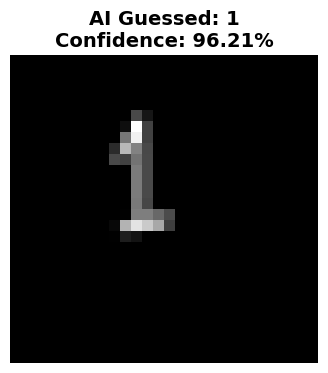

In [8]:
from google.colab import files
from PIL import Image, ImageOps
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch

def predict_custom_image():
    # 1. Trigger the Colab file upload prompt
    print("Upload a square image of a handwritten digit (e.g., drawn in MS Paint):")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print("No file uploaded. Stopping.")
        return

    # Grab the file name of the uploaded image
    file_name = list(uploaded.keys())[0]

    # 2. Open the image using Pillow (Python Image Library)
    raw_image = Image.open(file_name)

    # 3. Preprocess the image to match the exact MNIST format
    # - Convert to grayscale
    # - Invert colors (so the background becomes black and the digit becomes white)
    # - Resize to exactly 28x28 pixels
    processed_image = ImageOps.grayscale(raw_image)
    processed_image = ImageOps.invert(processed_image)
    processed_image = processed_image.resize((28, 28))

    # 4. Apply the same PyTorch transformations we used for training
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # Transform image and add the fake batch dimension
    input_tensor = transform(processed_image).unsqueeze(0).to(device)

    # 5. Let the AI make its guess
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted_label = torch.max(output, 1)

        # Get the confidence percentage of the guess
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence = probabilities[0][predicted_label.item()].item() * 100

    # 6. Display the final result
    plt.figure(figsize=(4, 4))

    # We display the processed image so you can see what the AI actually sees
    plt.imshow(processed_image, cmap='gray')
    plt.title(f"AI Guessed: {predicted_label.item()}\nConfidence: {confidence:.2f}%", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# Run it!
predict_custom_image()